<a href="https://colab.research.google.com/github/deepto123/Neural-Networks-and-LLMs/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install micrograd

In [ ]:
from micrograd.engine import Value

# Inputs
a = Value(-5.0)
b = Value(3.0)

# # Operations
# c = a + b
# d = a * b + b**3
# c += c + 1
# c += 1 + c + (-a)
# d += d * 2 + (b + a).relu()
# d += 3 * d + (b - a).relu()
# e = c - d
# f = e**2
# g = f / 2.0
# g += 10.0 / f

# print(f'{g.data:.4f}') # Outcome of the forward pass

# # Backward pass (calculates the gradients)
# g.backward()

# print(f'{a.grad:.4f}') # Numerical gradient of g with respect to a
# print(f'{b.grad:.4f}') # Numerical gradient of g with respect to b

In [ ]:
h = a*b + b
print(f"{h.data:.4f}")
h.backward()
print(f"{a.grad:.4f}")
print(f"{b.grad:.4f}")

-12.0000
3.0000
-4.0000


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def f(x):
  return 9*x**2 -6*x + 1

In [ ]:
f(2)

25

In [ ]:
xs = np.arange(-5, 5, 0.25)
print(xs)

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


In [ ]:
ys = f(xs)
print(ys)

[2.560000e+02 2.325625e+02 2.102500e+02 1.890625e+02 1.690000e+02
 1.500625e+02 1.322500e+02 1.155625e+02 1.000000e+02 8.556250e+01
 7.225000e+01 6.006250e+01 4.900000e+01 3.906250e+01 3.025000e+01
 2.256250e+01 1.600000e+01 1.056250e+01 6.250000e+00 3.062500e+00
 1.000000e+00 6.250000e-02 2.500000e-01 1.562500e+00 4.000000e+00
 7.562500e+00 1.225000e+01 1.806250e+01 2.500000e+01 3.306250e+01
 4.225000e+01 5.256250e+01 6.400000e+01 7.656250e+01 9.025000e+01
 1.050625e+02 1.210000e+02 1.380625e+02 1.562500e+02 1.755625e+02]


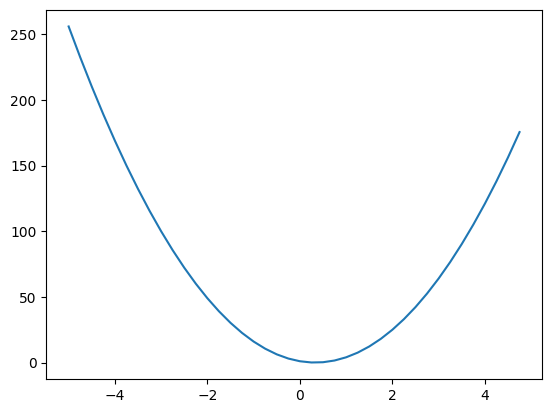

In [ ]:

plt.plot(xs, ys)

In [ ]:
h = .001
x = 0.5
(f(x+h) - f(x))/h

3.0089999999995953

In [ ]:
class Value:
  def __init__(self, data, _children = (), _operation = 'leaf_node'):
    self.data = data
    self.grad = 0.0
    self._children = set(_children)
    self._operation = _operation
    self.label = 'default'
    self._backward = lambda:None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __rmul__(self, other):
    return self*other

  def __radd__(self, other):
    return self + other

  # def __radd__(self, other):
  #   return self + other

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    output = Value(self.data + other.data, (self, other), '+')
    def _backward():
     self.grad += output.grad;
     other.grad += output.grad;
    output._backward = _backward
    return output

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    output = Value(self.data * other.data, (self, other), '*')
    def _backward():
     self.grad += other.data * output.grad;
     other.grad += self.data * output.grad;
    output._backward = _backward
    return output

  def __sub__(self, other):
    return self + (other *-1)

  def __truediv__(self, other):
    return self* other**-1

  def exp(self):
    output = Value(math.exp(self.data), (self, ), 'exp')
    def _backward():
      self.grad += output.data * output.grad
    output._backward = _backward
    return output

  def __pow__(self, power):
    output = Value(self.data**power, (self,), 'pow')
    def _backward():
      self.grad += power * (self.data**(power -1)) * output.grad
    output._backward = _backward
    return output


  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    # first we do topological sort to get the elements in order
    topo =[]
    visited = set()
    def build_topo(v) :
      if v not in visited:
        visited.add(v)
        for child in v._children:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


In [ ]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._children:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._operation!= "leaf_node":
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._operation, label = n._operation)
      # and connect this node to it
      dot.edge(uid + n._operation, uid)

  for n1, n2 in edges:
    # connect n1 to the op node
    dot.edge(str(id(n1)), str(id(n2)) + n2._operation)

  return dot


In [ ]:
a = Value(2.00); a.label = 'a'
b = Value(4.00); b.label = 'b'
c = Value(9.00); c.label = 'c'

d = a+b*c; d.label = 'd'
print(c)
print(c._children)
print(b._operation)
print(c._operation)
print(d)

Value(data=9.0)
set()
leaf_node
leaf_node
Value(data=38.0)


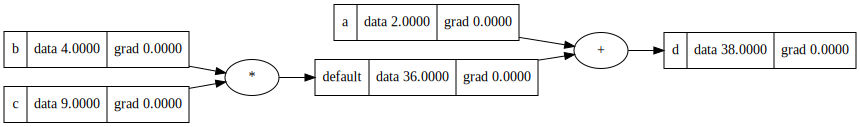

In [ ]:
draw_dot(d)

##**Loss function**

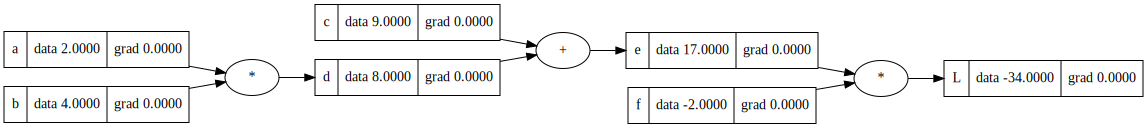

In [ ]:
a = Value(2.00); a.label = 'a'
b = Value(4.00); b.label = 'b'
c = Value(9.00); c.label = 'c'

d = a*b; d.label = 'd'
e = c+d; e.label = 'e'

f = Value(-2.00); f.label = 'f'

L = e*f; L.label = 'L'
draw_dot(L)

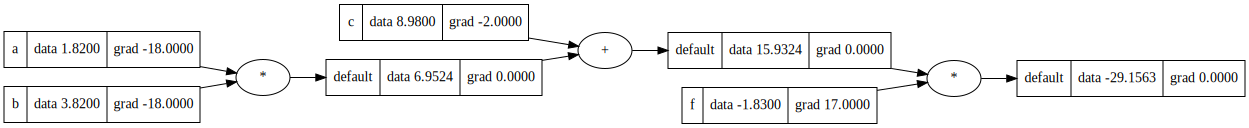

In [ ]:
L.grad = 1.00
f.grad = 17.0
e.grad = -2.0

#chain rule dL/dc = de/dc* dL/de = d(c+d)/dc * d(e*f)/de = f
c.grad = -2.0
d.grad = -2.0

a.grad = -18.0
b.grad = -18.0

# lets say there a fucntion y=-x. Gradient is -1. lets say x=4, y=-4.
# Now as we do x-=1*graident, we get x=3, y=-3 or value of y increases

a.data += .01* a.grad
b.data += .01* b.grad
c.data += .01* c.grad
f.data += .01* f.grad

d = a*b
e = c+d
L = e*f # L is expected to increase
draw_dot(L)

In [ ]:
def lol():
  a = Value(2.00); a.label = 'a'
  b = Value(4.00); b.label = 'b'
  c = Value(9.00); c.label = 'c'

  d = a*b; d.label = 'd' # Changed from a+b to a*b for consistency
  e = c+d; e.label = 'e'

  f = Value(-2.00); f.label = 'f'
  L = e*f; L.label = 'L'

  LInitial = L.data

  h = .001

  # Re-initialize values with the same base as for LInitial
  a = Value(2.00 + h); a.label = 'a'
  b = Value(4.00); b.label = 'b'
  c = Value(9.00); c.label = 'c'

  d = a*b; d.label = 'd'
  e = c+d; e.label = 'e'

  f = Value(-2.00); f.label = 'f'
  L = e*f; L.label = 'L'

  LFinal = L.data

  print((LFinal - LInitial)/h)

lol()


-7.999999999995566


# Implementing a neural network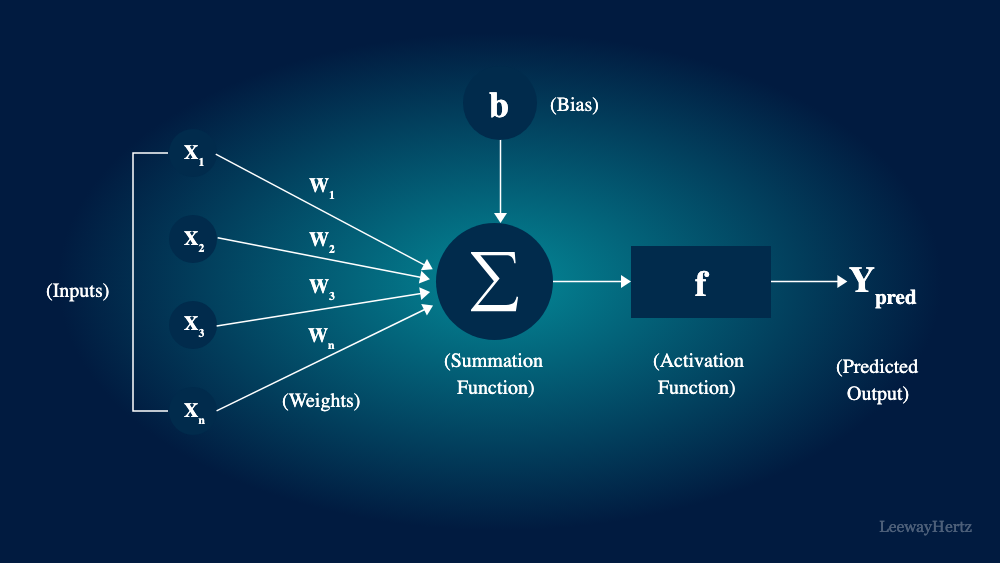

We will use tanh as the activation function

tanh(x) = (e^2x -1)/ (e^2x +1)
d(tanh(x))/dx = 1 - tanh(x)^2

[-5.0000000e+00 -4.8000000e+00 -4.6000000e+00 -4.4000000e+00
 -4.2000000e+00 -4.0000000e+00 -3.8000000e+00 -3.6000000e+00
 -3.4000000e+00 -3.2000000e+00 -3.0000000e+00 -2.8000000e+00
 -2.6000000e+00 -2.4000000e+00 -2.2000000e+00 -2.0000000e+00
 -1.8000000e+00 -1.6000000e+00 -1.4000000e+00 -1.2000000e+00
 -1.0000000e+00 -8.0000000e-01 -6.0000000e-01 -4.0000000e-01
 -2.0000000e-01  4.4408921e-15  2.0000000e-01  4.0000000e-01
  6.0000000e-01  8.0000000e-01  1.0000000e+00  1.2000000e+00
  1.4000000e+00  1.6000000e+00  1.8000000e+00  2.0000000e+00
  2.2000000e+00  2.4000000e+00  2.6000000e+00  2.8000000e+00
  3.0000000e+00  3.2000000e+00  3.4000000e+00  3.6000000e+00
  3.8000000e+00  4.0000000e+00  4.2000000e+00  4.4000000e+00
  4.6000000e+00  4.8000000e+00]
[-9.99909204e-01 -9.99864552e-01 -9.99797942e-01 -9.99698579e-01
 -9.99550366e-01 -9.99329300e-01 -9.98999598e-01 -9.98507942e-01
 -9.97774928e-01 -9.96682398e-01 -9.95054754e-01 -9.92631520e-01
 -9.89027402e-01 -9.83674858e-01 -9.75743

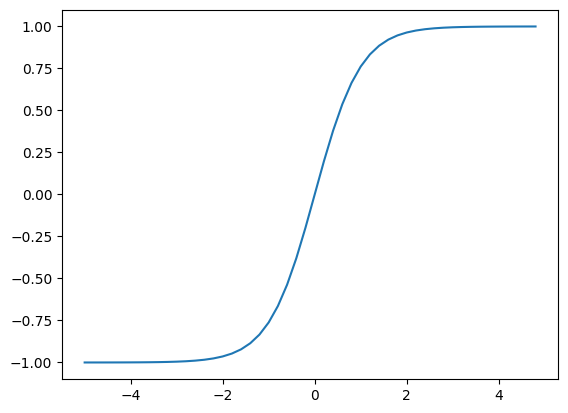

In [ ]:
xb = np.arange(-5,5,0.2)
yb = np.tanh(xb)
print(xb)
print(yb)
plt.plot(xb,yb)
plt.show()

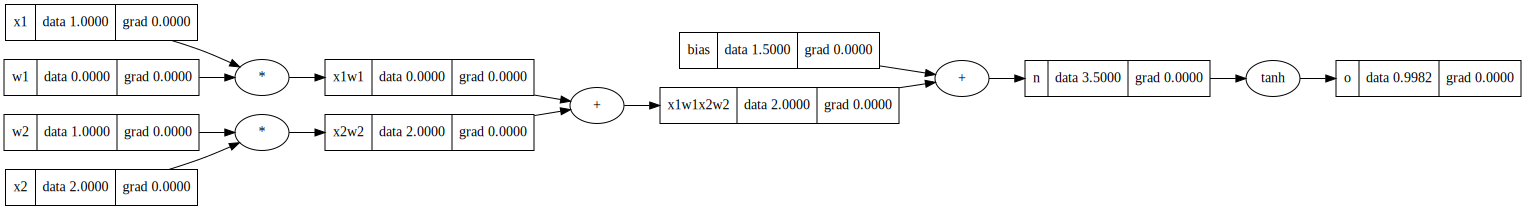

In [ ]:
x1 = Value(1.0); x1.label = 'x1'
w1 = Value(0.0); w1.label = 'w1'
x2 = Value(2.0); x2.label = 'x2'
w2 = Value(1.0); w2.label = 'w2'

bias = Value(1.5); bias.label = 'bias'
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + bias; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

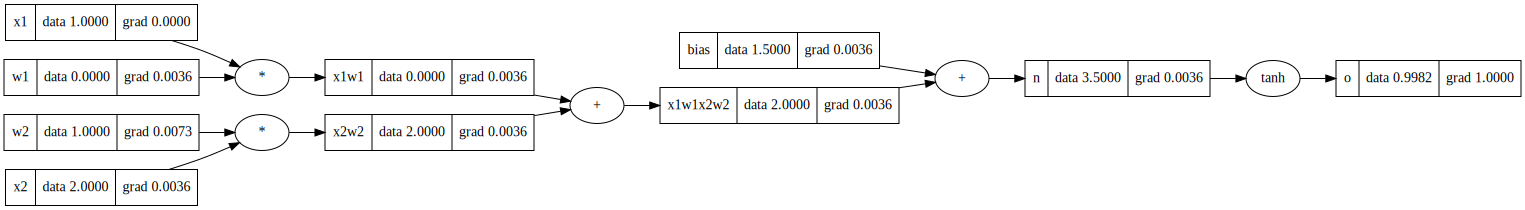

In [ ]:

o.grad = 1;
o._backward()
n._backward()
x1w1x2w2._backward()
bias._backward()
x1w1._backward()
x2w2._backward()
x2._backward()
x1._backward()
w2._backward()
w1._backward()


draw_dot(o)

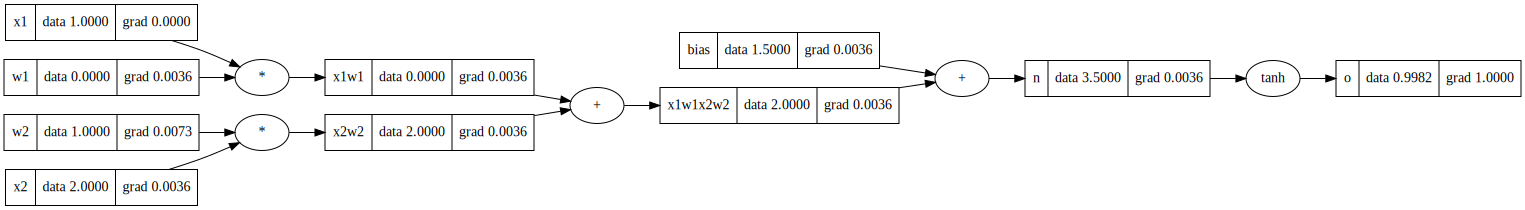

In [ ]:
#  do/do is always 1
o.grad = 1

# do/dn = 1- tanh^2x
n.grad = 1- o.data**2


bias.grad = n.grad
x1w1x2w2.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad

draw_dot(o)

### Resetting Gradients

Before performing a new backward pass, it's essential to reset the gradients to zero to prevent accumulation from previous computations. Here's how you can do it for the relevant `Value` objects:

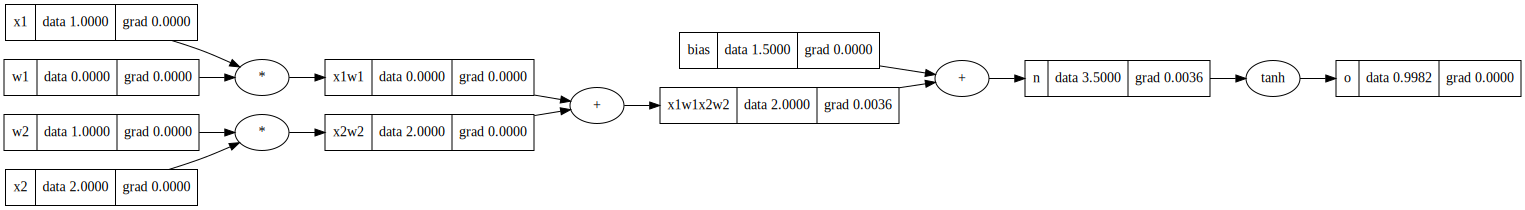

In [ ]:
def zero_grad():
    # Iterate through all Value objects that have a gradient and set it to 0.0
    # For this example, we'll reset the gradients for the leaf nodes (inputs and weights)
    x1.grad = 0.0
    w1.grad = 0.0
    x2.grad = 0.0
    w2.grad = 0.0
    x1w1.grad =0.0
    x2w2.grad = 0.0
    bias.grad = 0.0
    o.grad =0.0

    bias.grad = 0.0

zero_grad()
draw_dot(o)

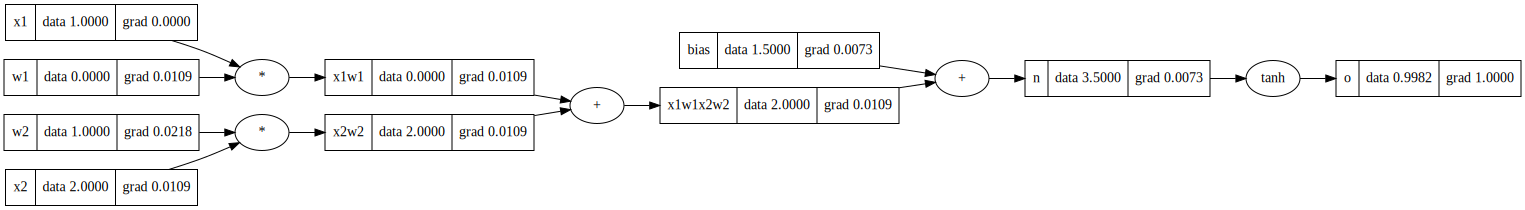

In [ ]:
o.grad = 1.0
o.backward()
draw_dot(o)

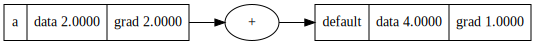

In [ ]:
a = Value(2.0); a.label = 'a'
b = a + a
b.grad = 1.0
b.backward()
draw_dot(b)

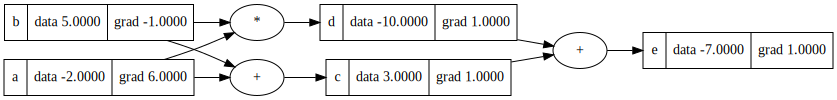

In [ ]:
a = Value(-2.0); a.label = 'a'
b = Value(5.0); b.label = 'b'
c = a + b; c.label = 'c'
d = a * b; d.label = 'd'
e = c + d; e.label = 'e'

e.backward()
draw_dot(e)

## Bug

We see that our current algo fails if variables are added to self or they are referenencing 2 variables that override them. Sp we do multivariable deriviative where we keep adding the deriviates to prev once

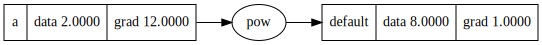

In [ ]:
a = Value(2.0); a.label = 'a'
b = a ** 3;
b.backward()
draw_dot(b)

To resolve this bug, we will check if a is a value and if not instantiate it with Value.

In [ ]:
x1 = Value(1.0); x1.label = 'x1'
w1 = Value(0.0); w1.label = 'w1'
x2 = Value(2.0); x2.label = 'x2'
w2 = Value(1.0); w2.label = 'w2'

bias = Value(1.5); bias.label = 'bias'
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + bias; n.label='n'
e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1)


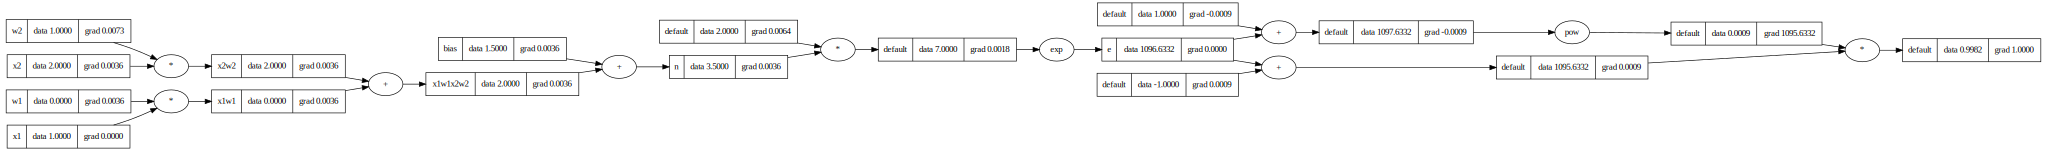

In [ ]:
o.backward()
draw_dot(o)

## Pytorch

In [ ]:
import torch

In [ ]:
newTensor = torch.Tensor([[1,2,3], [4,5,6]])

In [ ]:
newTensor.double().dtype

torch.float64

In [ ]:
x1 = torch.Tensor([1.0]).double(); x1.requires_grad = True
w1 = torch.Tensor([0.0]).double(); w1.requires_grad = True
x2 = torch.Tensor([2.0]).double(); x2.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
bias = torch.Tensor([1.5]).double(); bias.requires_grad = True

n = x1*w1 + x2*w2 + bias
o = torch.tanh(n)

print(o.data.item())
o.backward()


print("---")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.9981778976111987
---
x2 0.0036408847204873578
w2 0.0072817694409747155
x1 0.0
w1 0.0036408847204873578


In [ ]:
import random

class Neuron:
  def __init__(self, nin):
    # nin is the number of inputs to neuron
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w*x + b
    # We need to create pairs of x with w
    act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [b]

x=[1.0, 2.0, 3.0]
n = Neuron(3)
print(n(x).data)
print(n.parameters())

0.9428407514174082
[Value(data=0.31248468781929173), Value(data=-0.9735514937001593), Value(data=0.8150163351533222), Value(data=8.0)]


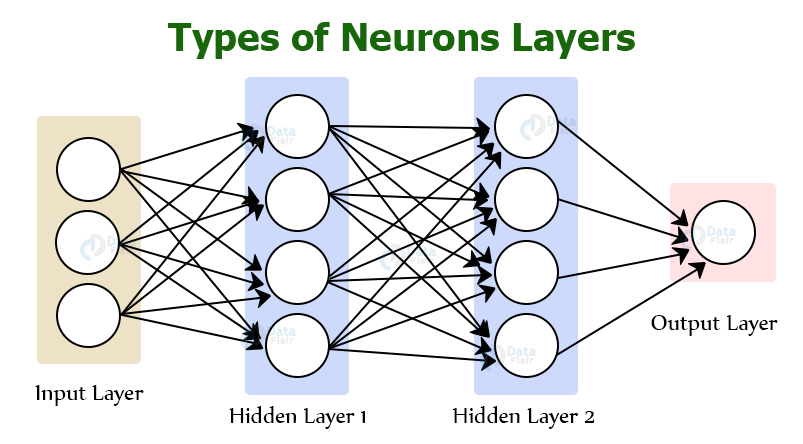

In [ ]:
class Layer:
  def __init__(self, nin, nout):
    # nin is the number of inputs to a single neuron in the layer and nout is
    # the number of neurons in the layer
    self.neurons = [Neuron(nin) for i in range(nout)]

  def __call__(self, x):
    # w*x + b
    nouts = [n(x) for n in self.neurons]
    return nouts

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

x=[1.0, 2.0, 3.0]
n = Layer(3, 4)
for neuron in n.neurons:
  print(neuron.w)

print(n(x))
print("parameters:", n.parameters())


[Value(data=0.06018528548304625), Value(data=-0.639464736488397), Value(data=0.08892557244272004)]
[Value(data=0.10725987811154347), Value(data=-0.05982684261285387), Value(data=0.3758104639617774)]
[Value(data=-0.8744682175863929), Value(data=-0.29807994874386434), Value(data=0.13148832856199366)]
[Value(data=-0.29537905562973865), Value(data=0.09482236450658776), Value(data=-0.6974562645924114)]
[Value(data=-0.29538760013641785), Value(data=0.7185353198549378), Value(data=-0.8530286465190611), Value(data=-0.9458121045818338)]
parameters: [Value(data=0.06018528548304625), Value(data=-0.639464736488397), Value(data=0.08892557244272004), Value(data=8.0), Value(data=0.10725987811154347), Value(data=-0.05982684261285387), Value(data=0.3758104639617774), Value(data=8.0), Value(data=-0.8744682175863929), Value(data=-0.29807994874386434), Value(data=0.13148832856199366), Value(data=8.0), Value(data=-0.29537905562973865), Value(data=0.09482236450658776), Value(data=-0.6974562645924114), Value

In [ ]:
class MLP:
  def __init__(self, nin, nouts):
    # in layer nout was a single number representing the size of the layer
    # here we will take an array of numbers representing the size of of each layer in multilayer perceptron network.
    sz = [nin] + nouts
    # sz array now contains all the layers size including input and output layers size

    # now we initialise a layer as number of inputs to it and the number of neurons in it
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    input = x
    # to get the output of MLP, get the output of eahc layer
    for layer in self.layers:
      out = layer(input)
      input = out

    if len(out) == 1:
      return out[0]
    return out

  def parameters(self):
      return [p for layer in self.layers for p in layer.parameters()]

x=[1.0, 2.0, 3.0]
n = MLP(3, [4,4,1])
n(x)
n.parameters()

[Value(data=-0.0941485240845259),
 Value(data=0.9828599913748874),
 Value(data=-0.22224300898309113),
 Value(data=Value(data=8.0)),
 Value(data=-0.7458491442069763),
 Value(data=0.5342258460294),
 Value(data=0.09630816855638957),
 Value(data=Value(data=8.0)),
 Value(data=-0.7926881172420344),
 Value(data=-0.23457662148894598),
 Value(data=-0.06729229175200935),
 Value(data=Value(data=8.0)),
 Value(data=0.708533733638137),
 Value(data=0.6248672363723429),
 Value(data=0.6282786215508478),
 Value(data=Value(data=8.0)),
 Value(data=-0.7207642686014093),
 Value(data=-0.05955106862943804),
 Value(data=-0.7246892964832825),
 Value(data=-0.18095907368887532),
 Value(data=Value(data=8.0)),
 Value(data=-0.1529329297249089),
 Value(data=-0.32790975206504713),
 Value(data=-0.6668032913872304),
 Value(data=-0.732717621605852),
 Value(data=Value(data=8.0)),
 Value(data=-0.42747031717055584),
 Value(data=-0.9162096514081151),
 Value(data=0.553253268047657),
 Value(data=-0.26312320424805025),
 Value(d

In [ ]:
xs = draw_dot(n(x))

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# inputs

ys = [1.0, -1.0, -1.0, 1.0] # desired targets




In [ ]:
ypred = [n(x) for x in xs]
print(ypred)

loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
print(loss)

[Value(data=0.990218077329288), Value(data=-0.9998166639213982), Value(data=-0.9886944871565143), Value(data=0.9932146333726397)]
Value(data=0.00026957544417542076)


In [ ]:
loss.backward()

In [ ]:
n.layers[0].neurons[0].w[0].grad

1.335190553706109

In [ ]:
# draw_dot(loss)

In [ ]:
for p in n.parameters():
  p.data += -0.1 * p.grad

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# inputs

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
n = MLP(3, [4, 4, 1])

for k in range(10000):

  # before doing backward reset all the grad to 0, as we do += on grad whcih may break our logic
  for p in n.parameters():
    p.grad = 0

  loss.backward()

  for p in n.parameters():
    p.data += -0.1 * p.grad

  ypred = [n(x) for x in xs]
  # print(ypred)

  loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
  # print(loss)

In [ ]:
print(ypred)

[Value(data=0.9980867232148926), Value(data=-0.9964583743431555), Value(data=-0.9975359816270692), Value(data=0.9969202426221191)]
